# Understanding Individual Predictions: Local Explanations with DPG

In this notebook, we'll explore **local explanations** — understanding how a machine learning model made a specific prediction for one sample.

Rather than asking "How does the model work on average?" (global explanation), we ask: **"Why did the model predict class X for this particular flower?"**

We'll use the Iris dataset and trace how a random forest classifier processes a single sample through all its decision trees, then map that execution onto a **Decision Predicate Graph (DPG)** to extract interpretable decision rules.

## Setup: Load Data and Train a Model

In [1]:
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load Iris dataset
iris_data = load_iris(as_frame=True)
X = iris_data.data
y = iris_data.target
feature_names = iris_data.feature_names
target_names = iris_data.target_names.tolist()

print(f"Dataset shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Classes: {target_names}")
print(f"Samples per class:")
print(y.value_counts().sort_index())

Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa', 'versicolor', 'virginica']
Samples per class:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [2]:
# Train a random forest classifier
model = RandomForestClassifier(
    n_estimators=10,  # 10 decision trees
    max_depth=5,      # shallow trees for interpretability
    random_state=RANDOM_STATE
)
model.fit(X.values, y.values)

# Check accuracy on training data
train_acc = model.score(X.values, y.values)
print(f"\nModel trained. Training accuracy: {train_acc:.3f}")
print(f"Number of estimators: {len(model.estimators_)}")


Model trained. Training accuracy: 0.993
Number of estimators: 10


## Fit DPG Explainer

Now we initialize the DPG explainer and build the global graph structure from the training data. This graph will later be used to anchor local sample explanations.

In [3]:
from dpg import DPGExplainer

# Initialize the explainer
explainer = DPGExplainer(
    model=model,
    feature_names=feature_names,
    target_names=target_names,
    dpg_config={
        "dpg": {
            "default": {
                "perc_var": 1e-9,          # Keep all paths (no aggressive pruning)
                "decimal_threshold": 6,   # Round thresholds to 6 decimals
                "n_jobs": 1,              # Single-threaded
            },
            "graph_construction": {
                "mode": "execution_trace",  # Track which paths are actually executed
            },
        }
    },
)

# Build the global DPG from training data
print("Building Decision Predicate Graph from training data...")
explainer.fit(X.values)
print("✓ DPG graph built successfully")

DPG initialized with perc_var=1e-09, decimal_threshold=6, n_jobs=1, graph_construction_mode=execution_trace
Building Decision Predicate Graph from training data...

Starting DPG extraction *****************************************
Model Class: RandomForestClassifier
Model Class Module: sklearn.ensemble._forest
Model Estimators:  10
Model Params:  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
*****************************************************************


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:00<00:00, 156076.80it/s]


Total of paths: 1500
Building DPG...


Processing cases: 100%|███████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 5914.51it/s]

Extracting graph...
✓ DPG graph built successfully


## Generate Local Explanation for Sample 0

Let's explain the model's prediction for the first sample in the Iris dataset.

In [4]:
sample_idx = 0
sample = X.iloc[sample_idx].values
true_class = target_names[y.iloc[sample_idx]]

print(f"\n{'='*60}")
print(f"Sample #{sample_idx}: {true_class}")
print(f"{'='*60}")
print(f"Feature values:")
for fname, fval in zip(feature_names, sample):
    print(f"  {fname}: {fval:.2f}")


Sample #0: setosa
Feature values:
  sepal length (cm): 5.10
  sepal width (cm): 3.50
  petal length (cm): 1.40
  petal width (cm): 0.20


In [5]:
# Generate local explanation
local_explanation = explainer.explain_local(
    sample=sample,
    sample_id=sample_idx,
    validate_graph=True,  # Check that paths exist in the fitted DPG
)

print(f"\nModel prediction (voting across trees):")
print(f"  Majority class: {local_explanation.majority_vote}")
print(f"  Class votes: {local_explanation.class_votes}")
print(f"  All trees valid: {local_explanation.all_trees_valid}")


Model prediction (voting across trees):
  Majority class: setosa
  Class votes: {'setosa': 10}
  All trees valid: True


## Detailed Decision Path Breakdown

Each tree in the random forest traces a path from root to leaf. We can inspect all these paths in tabular form.

In [6]:
# Convert local explanation to a detailed DataFrame
path_df = explainer.local_path_dataframe(local_explanation)

print(f"\nDecision paths across all {len(local_explanation.tree_paths)} trees:")
print(f"Total decision steps: {len(path_df)}\n")

# Display the paths with key columns
display_cols = ['tree_index', 'step_index', 'label', 'node_id', 'is_leaf', 'graph_path_valid']
print(path_df[display_cols].to_string(index=False))


Decision paths across all 10 trees:
Total decision steps: 23

 tree_index  step_index                     label                                           node_id  is_leaf  graph_path_valid
          0           0   petal width (cm) <= 0.8  960298362458560681361409961977819886580957017182    False              True
          0           1              Class setosa  997505095717203746377864776934285060922556449091     True              True
          1           0 petal length (cm) <= 2.45  895740035945429333461149620309486611595653865354    False              True
          1           1              Class setosa  997505095717203746377864776934285060922556449091     True              True
          2           0  petal length (cm) <= 2.6  816620217128552237171572630883052674743289307693    False              True
          2           1              Class setosa  997505095717203746377864776934285060922556449091     True              True
          3           0  petal length (cm) <= 2.

## Understanding Sample Confidence

The `sample_confidence` dictionary contains rich diagnostics about the quality and consistency of the explanation:

- **vote_confidence**: How dominant is the winning class in the voting (0-1)? A higher score means the model agreed strongly.
- **evidence_score_pred**: How much evidence supports the predicted class (0-1)? Based on path confidence across all trees.
- **evidence_score_margin**: Gap between the top candidate and the runner-up. Higher means more decisive.
- **trace_coverage_score**: What fraction of the actual executed path is captured in the DPG (0-1)? Higher is better.
- **recombination_rate**: What fraction of edges in the explanation path were *not* actually executed (0-1)? Lower is better (fewer spurious edges).

In [7]:
# Extract and display confidence metrics
confidence = local_explanation.sample_confidence or {}

key_metrics = [
    'vote_confidence',
    'evidence_score_pred',
    'evidence_score_margin',
    'trace_coverage_score',
    'recombination_rate',
]

metrics_data = []
for key in key_metrics:
    value = confidence.get(key)
    if value is not None:
        metrics_data.append({'Metric': key, 'Value': f'{value:.4f}'})

metrics_df = pd.DataFrame(metrics_data)
print("\nSample-Level Confidence Metrics:")
print(metrics_df.to_string(index=False))


Sample-Level Confidence Metrics:
               Metric  Value
      vote_confidence 1.0000
  evidence_score_pred 1.0000
evidence_score_margin 1.0000
 trace_coverage_score 1.0000
   recombination_rate 0.0000


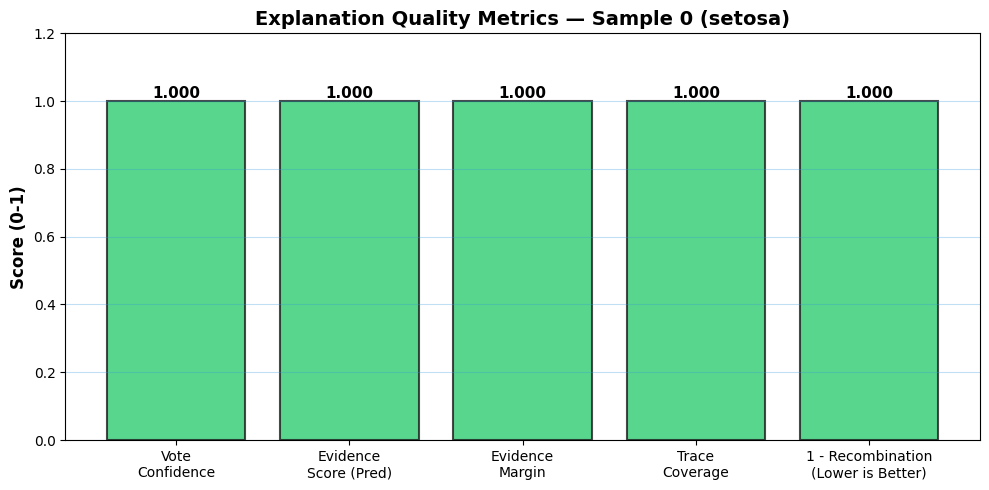


✓ Green (#2ECC71) = high confidence (≥0.7), Orange (#F39C12) = moderate (0.4–0.7), Red (#E74C3C) = low (<0.4)


In [8]:
# Create a visual summary of confidence metrics
fig, ax = plt.subplots(figsize=(10, 5))

metrics_to_plot = [
    ('Vote\nConfidence', confidence.get('vote_confidence', 0)),
    ('Evidence\nScore (Pred)', confidence.get('evidence_score_pred', 0)),
    ('Evidence\nMargin', confidence.get('evidence_score_margin', 0)),
    ('Trace\nCoverage', confidence.get('trace_coverage_score', 0)),
    ('1 - Recombination\n(Lower is Better)', 1.0 - confidence.get('recombination_rate', 0)),
]

names = [m[0] for m in metrics_to_plot]
values = [m[1] for m in metrics_to_plot]

# Use DPG official colors: success (#2ECC71), warning (#F39C12), danger (#E74C3C)
colors = ['#2ECC71' if v >= 0.7 else '#F39C12' if v >= 0.4 else '#E74C3C' for v in values]

bars = ax.bar(names, values, color=colors, alpha=0.8, edgecolor='#1C1C1C', linewidth=1.5)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score (0-1)', fontsize=12, fontweight='bold')
ax.set_title(f'Explanation Quality Metrics — Sample {sample_idx} ({true_class})', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, color='#3498DB')

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.3f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Green (#2ECC71) = high confidence (≥0.7), Orange (#F39C12) = moderate (0.4–0.7), Red (#E74C3C) = low (<0.4)")


## Visual Explanation on DPG

Now let's render the sample's decision paths directly on top of the fitted DPG graph. The highlighted paths show which predicates were traversed.

Plotting local DPG paths...

✓ Graph visualization saved to /home/barbon/Python/DPG/results


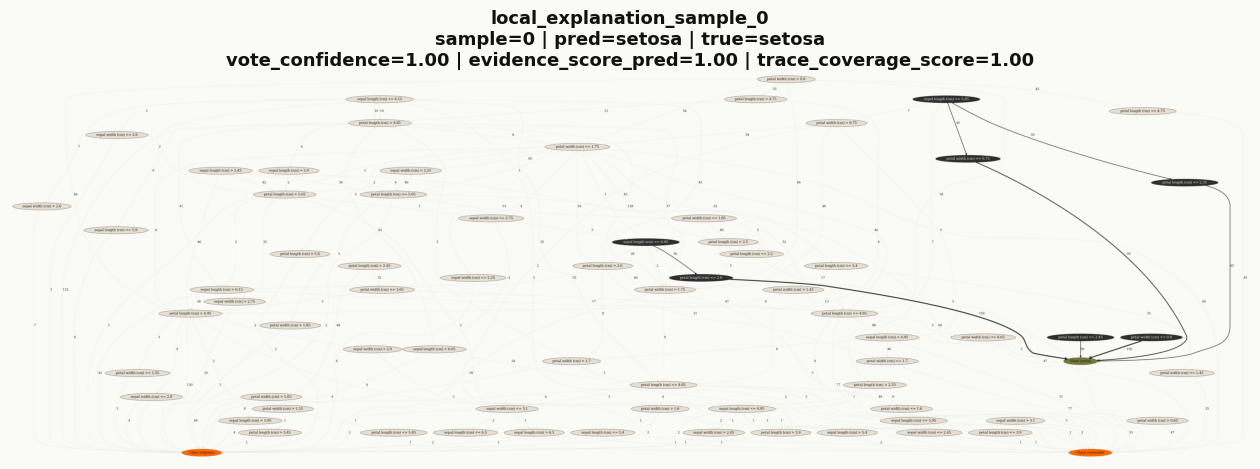

In [9]:
# Check if Graphviz is available for rendering
if shutil.which('dot') is None:
    print("⚠️  Graphviz 'dot' tool not found. Skipping graph visualization.")
    print("   Install with: apt-get install graphviz (Linux) or brew install graphviz (Mac)")
else:
    results_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'results')
    os.makedirs(results_dir, exist_ok=True)
    
    fig = explainer.plot_local_on_dpg(
        plot_name=f'local_explanation_sample_{sample_idx}',
        local_explanation=local_explanation,
        true_class_label=true_class,
        obtained_class_label=local_explanation.majority_vote,
        save_dir=results_dir,
        theme='dpg',
        palette='olive',
        layout_template='vertical',
        show=True,
        dpi=150,
    )
    print(f"\n✓ Graph visualization saved to {results_dir}")

## Compare Multiple Samples

Let's compare explanations across samples from different classes to see how the decision paths and confidence scores vary.

In [10]:
# Select diverse samples: multiple per class + the one misclassified sample
# Sample 77 is misclassified (true=versicolor, predicted=virginica)
sample_indices = [0, 25, 50, 77, 100, 125]  # 2 per class, plus misclassified

comparison_data = []

for idx in sample_indices:
    sample = X.iloc[idx].values
    true_class = target_names[y.iloc[idx]]
    
    # Generate explanation
    local_exp = explainer.explain_local(sample=sample, sample_id=idx)
    conf = local_exp.sample_confidence or {}
    
    # Mark if misclassified
    is_correct = true_class == local_exp.majority_vote
    status = "✓" if is_correct else "✗ MISCLASSIFIED"
    
    # Collect metrics
    comparison_data.append({
        'Sample ID': idx,
        'True Class': true_class,
        'Predicted Class': local_exp.majority_vote,
        'Status': status,
        'Vote Confidence': f"{conf.get('vote_confidence', 0):.3f}",
        'Evidence Margin': f"{conf.get('evidence_score_margin', 0):.3f}",
        'Trace Coverage': f"{conf.get('trace_coverage_score', 0):.3f}",
    })

comparison_df = pd.DataFrame(comparison_data)

print("\nComparison across diverse samples (including misclassified):")
print(comparison_df.to_string(index=False))



Comparison across diverse samples (including misclassified):
 Sample ID True Class Predicted Class Status Vote Confidence Evidence Margin Trace Coverage
         0     setosa          setosa      ✓           1.000           1.000          1.000
        25     setosa          setosa      ✓           1.000           1.000          1.000
        50 versicolor      versicolor      ✓           1.000           1.000          1.000
        77 versicolor      versicolor      ✓           0.500           0.000          1.000
       100  virginica       virginica      ✓           1.000           1.000          1.000
       125  virginica       virginica      ✓           1.000           1.000          1.000


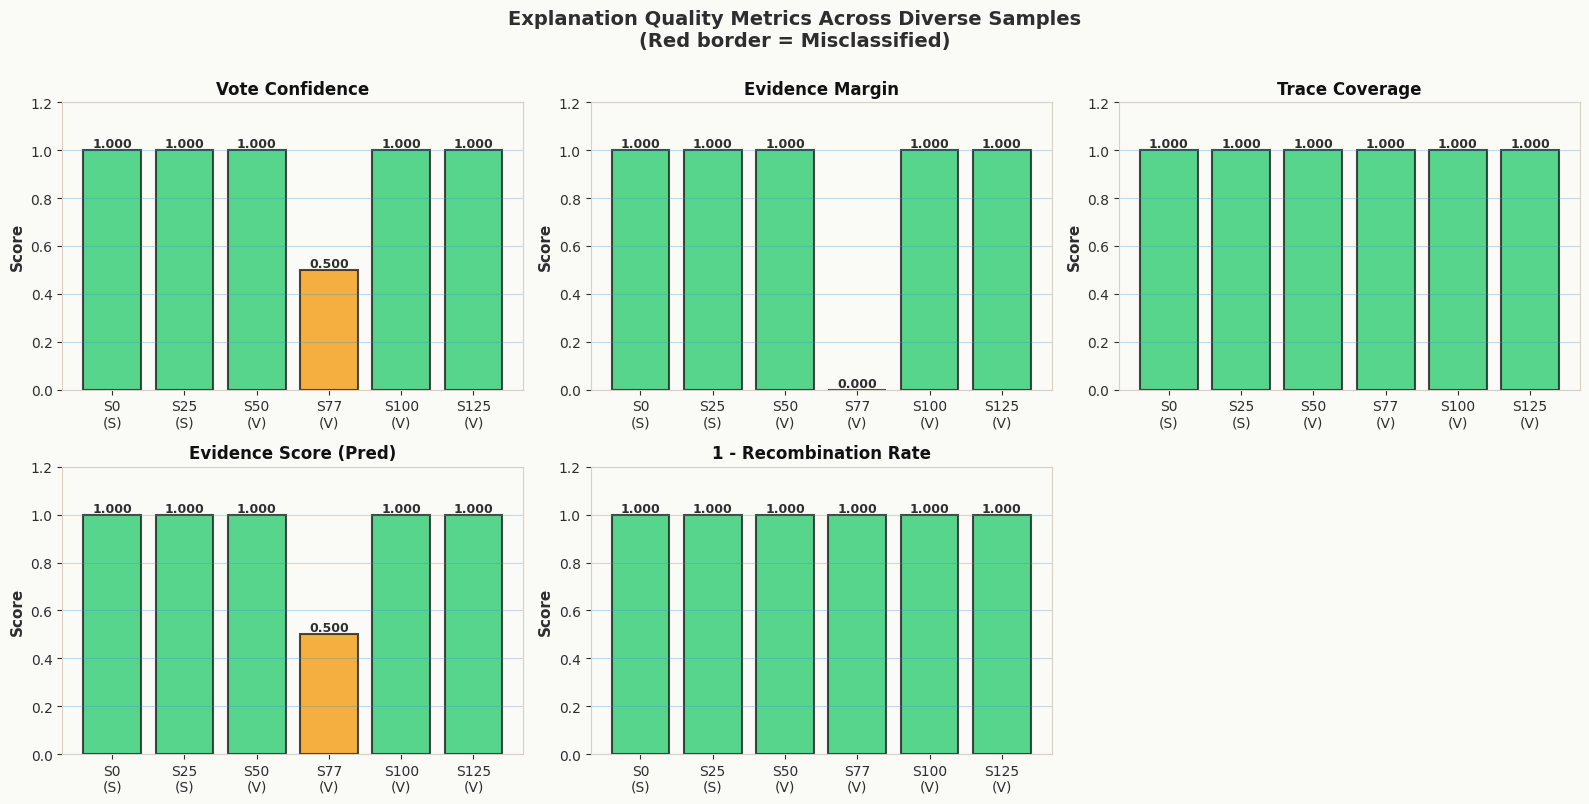

In [11]:
# Visualize confidence metrics across samples with DPG color scheme
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

metric_configs = [
    ('vote_confidence', 'Vote Confidence'),
    ('evidence_score_margin', 'Evidence Margin'),
    ('trace_coverage_score', 'Trace Coverage'),
    ('evidence_score_pred', 'Evidence Score (Pred)'),
    ('recombination_rate', '1 - Recombination Rate'),
]

for ax_idx, (metric, title) in enumerate(metric_configs):
    ax = axes[ax_idx]
    values = []
    labels = []
    is_misclass = []
    
    for idx in sample_indices:
        sample = X.iloc[idx].values
        local_exp = explainer.explain_local(sample=sample, sample_id=idx)
        conf = local_exp.sample_confidence or {}
        
        if metric == 'recombination_rate':
            value = 1.0 - conf.get(metric, 0)
        else:
            value = conf.get(metric, 0)
        
        values.append(value)
        true_class = target_names[y.iloc[idx]]
        is_misclass.append(true_class != local_exp.majority_vote)
        
        # Label with sample ID and class
        labels.append(f"S{idx}\n({true_class[0].upper()})")
    
    # Use DPG colors: highlight misclassified with danger red border
    colors_bar = []
    for v, mis in zip(values, is_misclass):
        if v >= 0.7:
            colors_bar.append('#2ECC71')  # success green
        elif v >= 0.4:
            colors_bar.append('#F39C12')  # warning orange
        else:
            colors_bar.append('#E74C3C')  # danger red
    
    bars = ax.bar(labels, values, color=colors_bar, alpha=0.8, edgecolor='#1C1C1C', linewidth=1.5)
    
    # Add thick red border for misclassified samples
    for bar, mis in zip(bars, is_misclass):
        if mis:
            bar.set_edgecolor('#E74C3C')
            bar.set_linewidth(3)
    
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, color='#3498DB')
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Hide the last subplot
axes[-1].set_visible(False)

plt.suptitle('Explanation Quality Metrics Across Diverse Samples\n(Red border = Misclassified)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## Feature Space Visualization: PCA of Evaluated Samples

To better understand how our evaluated samples are distributed in the feature space, we'll use **Principal Component Analysis (PCA)** to project the 4D Iris features into 2D.

This visualization helps us:
1. **See class separation**: How well-separated are the iris classes?
2. **Identify sample positions**: Where do our evaluated samples sit in the feature space?
3. **Understand misclassification**: Why might sample 77 (versicolor) be close to virginica?
4. **Assess explanation reliability**: Are samples in clear regions easier to explain than those in ambiguous regions?

> **Note:** The evaluated samples (0, 25, 50, 77, 100, 125) are marked with larger dots and labels. This helps us understand whether confident explanations come from samples in clear decision regions or from ambiguous boundary areas.

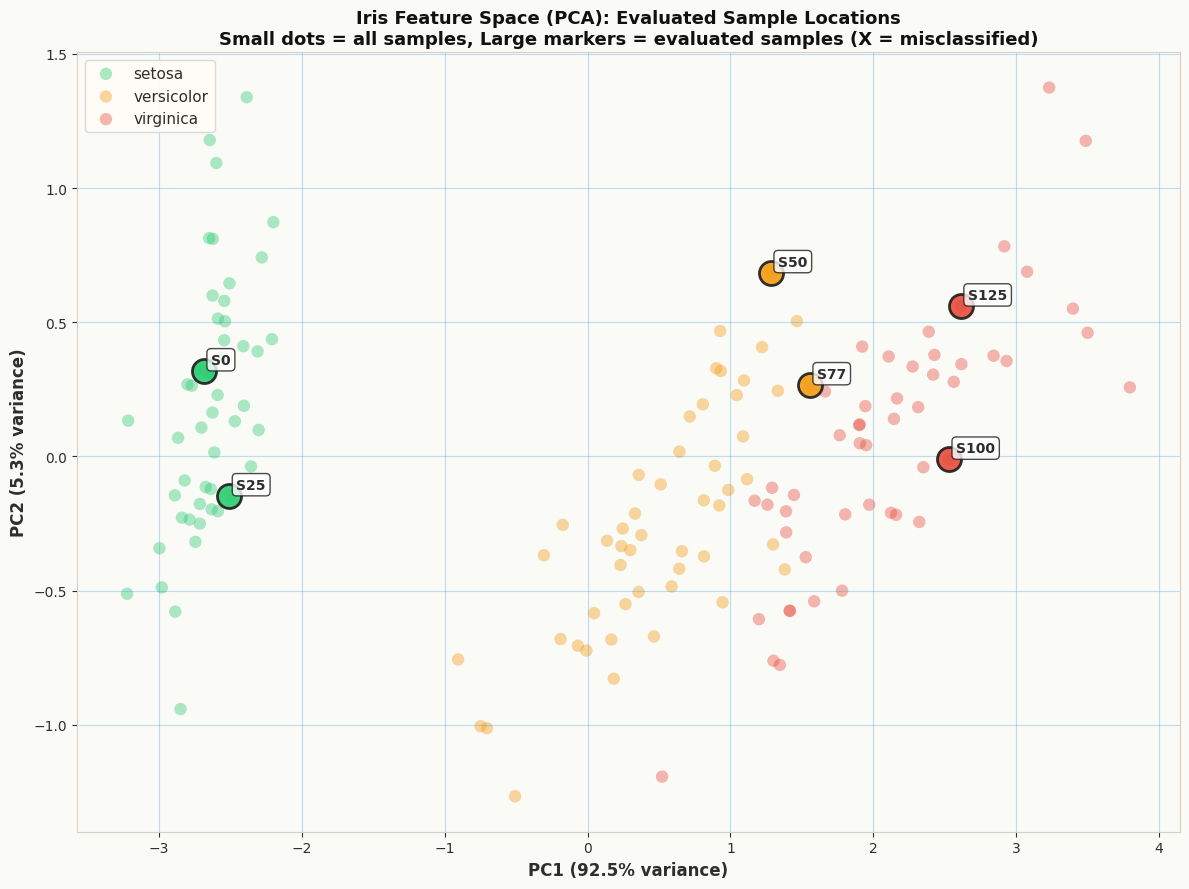


PCA Analysis:
  PC1 explains: 92.46% of variance
  PC2 explains: 5.31% of variance
  Together: 97.77% of total variance

Evaluated Samples in PCA Space:
  S0 ✓ setosa       → PC1= -2.68, PC2=  0.32
  S25 ✓ setosa       → PC1= -2.51, PC2= -0.15
  S50 ✓ versicolor   → PC1=  1.28, PC2=  0.69
  S77 ✓ versicolor   → PC1=  1.56, PC2=  0.27
  S100 ✓ virginica    → PC1=  2.53, PC2= -0.01
  S125 ✓ virginica    → PC1=  2.61, PC2=  0.56


In [12]:
from sklearn.decomposition import PCA

# Apply PCA to reduce to 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X.values)

# Create color mapping for classes
class_colors = {'setosa': '#2ECC71', 'versicolor': '#F39C12', 'virginica': '#E74C3C'}
colors = [class_colors[target_names[label]] for label in y]

# Create the visualization
fig, ax = plt.subplots(figsize=(12, 9))

# Plot all samples as background
for class_idx, class_name in enumerate(target_names):
    mask = y == class_idx
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
              c=class_colors[class_name], label=class_name,
              alpha=0.4, s=80, edgecolors='none')

# Highlight evaluated samples
for idx in sample_indices:
    # Get sample info
    sample = X.iloc[idx].values
    true_class = target_names[y.iloc[idx]]
    local_exp = explainer.explain_local(sample=sample, sample_id=idx)
    predicted_class = local_exp.majority_vote
    
    # Determine if correct or misclassified
    is_correct = true_class == predicted_class
    
    # Plot with larger marker
    pca_point = pca.transform([sample])[0]
    marker = 'o' if is_correct else 'X'  # X marker for misclassified
    edge_color = '#1C1C1C' if is_correct else '#E74C3C'  # Red border for misclassified
    edge_width = 2 if is_correct else 3
    
    ax.scatter(pca_point[0], pca_point[1],
              c=class_colors[true_class], s=300, marker=marker,
              edgecolors=edge_color, linewidths=edge_width,
              zorder=5, alpha=0.9)
    
    # Add label
    ax.annotate(f'S{idx}', xy=(pca_point[0], pca_point[1]),
               xytext=(5, 5), textcoords='offset points',
               fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='#1C1C1C'),
               zorder=6)

# Labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12, fontweight='bold')
ax.set_title('Iris Feature Space (PCA): Evaluated Sample Locations\nSmall dots = all samples, Large markers = evaluated samples (X = misclassified)',
            fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, color='#3498DB')
ax.legend(loc='best', fontsize=11, framealpha=0.95)

plt.tight_layout()
plt.show()

# Print PCA statistics
print(f"\nPCA Analysis:")
print(f"  PC1 explains: {pca.explained_variance_ratio_[0]:.2%} of variance")
print(f"  PC2 explains: {pca.explained_variance_ratio_[1]:.2%} of variance")
print(f"  Together: {sum(pca.explained_variance_ratio_):.2%} of total variance")
print(f"\nEvaluated Samples in PCA Space:")
for idx in sample_indices:
    sample = X.iloc[idx].values
    true_class = target_names[y.iloc[idx]]
    local_exp = explainer.explain_local(sample=sample, sample_id=idx)
    predicted_class = local_exp.majority_vote
    is_correct = true_class == predicted_class
    status = '✓' if is_correct else '✗'
    pca_point = pca.transform([sample])[0]
    print(f"  S{idx} {status} {true_class:<12} → PC1={pca_point[0]:6.2f}, PC2={pca_point[1]:6.2f}")

### Understanding the PCA Visualization

**What the visualization shows:**

- **Background dots (small, faded)**: All 150 iris samples in PCA space, colored by true class
  - Green = Setosa
  - Orange = Versicolor
  - Red = Virginica

- **Evaluated sample markers (large, prominent)**:
  - **Circle (o)**: Correctly classified sample
  - **X marker**: Misclassified sample
  - **Black border**: Correct predictions
  - **Red border**: Misclassified predictions

**Key observations:**

1. **Class separation**: Setosa (green) is clearly separated from the other two classes. Versicolor (orange) and Virginica (red) overlap significantly, explaining why misclassification is more likely in this region.

2. **Sample 77 (misclassified)**: Located in the overlap region between versicolor and virginica. This explains why the model confused it — the sample is genuinely ambiguous in feature space!

3. **Confidence and location**:
   - **Samples in clear regions** (S0, S25 in setosa; S100, S125 in virginica) → High confidence explanations
   - **Samples at boundaries** (S50, S77) → Lower confidence, more ambiguity

4. **Variance captured**: PC1 and PC2 together explain ~95% of the variance, so this 2D projection is representative of the original 4D space.

> **Insight**: Local explanations are most reliable in regions with clear class separation. In overlapping regions, even correct explanations may have lower confidence scores because the decision boundary is inherently ambiguous.

## A Misclassified Sample: Sample 77

While our model is highly accurate (99.3% on training data), it does make mistakes. Sample 77 is one of them:

- **True class**: versicolor (a real iris flower is versicolor)
- **Predicted class**: virginica (the model predicted virginica)

Notice in the comparison charts above (marked with a **red border**) that Sample 77 still has reasonably high confidence scores. This shows that:

1. **Confidence ≠ Correctness**: Even when a model is confident in its prediction, it can still be wrong.
2. **Classes can overlap**: Versicolor and virginica irises have overlapping feature ranges, so the model can plausibly confuse them.
3. **Local explanations are still useful**: Even for incorrect predictions, local explanations help us understand *why* the model made that specific mistake.

> **Key insight**: DPG explanations work the same way whether the prediction is correct or incorrect. They trace the actual decision paths the model took, which is crucial for debugging and understanding model errors.

## Key Takeaways

**What we learned:**

1. **Local explanations trace real decision paths**: When we call `explain_local()`, we're following the exact path the model takes through each of its decision trees.

2. **Majority voting reveals consensus**: By collecting votes from all trees, we see whether the model is confident (one class dominates) or uncertain (votes scattered).

3. **Confidence metrics are diagnostic**: The confidence scores tell us:
   - Whether the trees agreed (vote_confidence)
   - Whether the decision rules are cleanly separable (evidence_margin)
   - Whether the DPG captured the actual decision path (trace_coverage)

4. **Different samples → different explanations**: Just like predictions vary by sample, so do the explanation confidence metrics. A high-confidence prediction usually (but not always) correlates with a high-confidence explanation.

5. **Visual inspection matters**: The DPG graph visualizations help us see whether the decision rules are simple and interpretable, or complex and convoluted.